In [78]:
#Imports

import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import tensorflow as tf

In [79]:
#Read data

# Define the file paths
subdirectory = "./3_Model/pickle_data"
training_features_path = f"{subdirectory}/training_features.pkl"
validation_features_path = f"{subdirectory}/validation_features.pkl"
test_features_path = f"{subdirectory}/test_features.pkl"
training_labels_path = f"{subdirectory}/training_labels.pkl"
validation_labels_path = f"{subdirectory}/validation_labels.pkl"
test_labels_path = f"{subdirectory}/test_labels.pkl"

# Read the pickle files
training_features = pd.read_pickle(training_features_path)
validation_features = pd.read_pickle(validation_features_path)
test_features = pd.read_pickle(test_features_path)
training_labels = pd.read_pickle(training_labels_path)
validation_labels = pd.read_pickle(validation_labels_path)
test_labels = pd.read_pickle(test_labels_path)

#ΝΟΡΜΑLΙΖΑΤΙΟΝ
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()
# Fit ONLY on training features
training_features = scaler.fit_transform(training_features)
# Transform validation and test features using the same scaler
validation_features = scaler.transform(validation_features)
test_features = scaler.transform(test_features)


In [ ]:
#just experimenting with a loop for different model configurations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# MAPE function
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Plot predictions
def plot_predictions(preds, actuals, title):
    df = pd.DataFrame({'Predicted': preds, 'Actual': actuals})
    plt.figure(figsize=(10, 4))
    plt.plot(df['Actual'][:100], label='Actual', color='red')
    plt.plot(df['Predicted'][:100], label='Predicted', color='blue')
    plt.title(title)
    plt.xlabel("Sample")
    plt.ylabel("Umsatz")
    plt.legend()
    plt.show()

# Different model configs to try
configs = [
    {"dropout": False, "l2": False, "activation": "relu"},
    {"dropout": True,  "l2": False, "activation": "relu"},
    {"dropout": False, "l2": True,  "activation": "relu"},
    {"dropout": False, "l2": False, "activation": "sigmoid"},
]

# Training loop for all configurations
for i, config in enumerate(configs):
    print(f"\n=== Training Model {i+1} | Config: {config} ===")

    model = Sequential()
    model.add(InputLayer(shape=(training_features.shape[1],)))
    model.add(BatchNormalization())

    regularizer = l2(1e-3) if config["l2"] else None

    model.add(Dense(16, activation=config["activation"], kernel_regularizer=regularizer))
    if config["dropout"]:
        model.add(Dropout(0.2))
    model.add(Dense(8, activation=config["activation"], kernel_regularizer=regularizer))
    model.add(Dense(1))

    model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))

    early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    history = model.fit(
        training_features, training_labels,
        validation_data=(validation_features, validation_labels),
        epochs=200,
        callbacks=[early_stop],
        verbose=0  # Set to 1 to see progress
    )

    # Plot loss
    plt.figure(figsize=(8, 3))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"Loss - Model {i+1}")
    plt.legend()
    plt.show()

    # Evaluate
    train_preds = model.predict(training_features).flatten()
    val_preds = model.predict(validation_features).flatten()

    train_mape = mape(training_labels, train_preds)
    val_mape = mape(validation_labels, val_preds)

    print(f"Train MAPE: {train_mape:.2f}% | Val MAPE: {val_mape:.2f}%")

    # Plot predictions
    plot_predictions(val_preds, validation_labels, f"Model {i+1} - Val Set Predictions")


In [ ]:
#from this model 3 was good so i'll build on that 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, InputLayer
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

def train_model(config, train_X, train_y, val_X, val_y):
    model = Sequential()
    model.add(InputLayer(shape=(train_X.shape[1],)))
    model.add(BatchNormalization())
    
    regularizer = l2(config.get("l2_lambda", 0)) if config.get("l2", False) else None
    
    # Add first hidden layer
    model.add(Dense(config.get("layer1_size", 16), 
                    activation=config.get("activation1", "relu"),
                    kernel_regularizer=regularizer))
    
    if config.get("dropout", False):
        model.add(Dropout(config.get("dropout_rate", 0.2)))
    
    # Add second hidden layer
    model.add(Dense(config.get("layer2_size", 8), 
                    activation=config.get("activation2", config.get("activation1", "relu")),
                    kernel_regularizer=regularizer))
    
    model.add(Dense(1))  # Output layer
    
    optimizer = Adam(learning_rate=config.get("learning_rate", 0.001))
    model.compile(loss='mse', optimizer=optimizer)
    
    early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
    
    history = model.fit(
        train_X, train_y,
        validation_data=(val_X, val_y),
        epochs=config.get("epochs", 200),
        callbacks=[early_stop],
        verbose=0
    )
    
    # Plot loss
    plt.figure(figsize=(8, 3))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Loss")
    plt.legend()
    plt.show()
    
    # Predictions and MAPE
    train_preds = model.predict(train_X).flatten()
    val_preds = model.predict(val_X).flatten()
    
    train_mape = mape(train_y, train_preds)
    val_mape = mape(val_y, val_preds)
    
    print(f"Train MAPE: {train_mape:.2f}% | Val MAPE: {val_mape:.2f}%")
    plot_predictions(val_preds, val_y, "Validation Predictions")
    
    return model, history, val_mape

# Example configs to try your adjustments
configs = [
    {"dropout": False, "l2": False, "activation1": "relu", "activation2": "relu",
     "layer1_size": 16, "layer2_size": 8, "learning_rate": 0.001},
    
    {"dropout": True, "dropout_rate": 0.3, "l2": False, "activation1": "relu", "activation2": "relu",
     "layer1_size": 32, "layer2_size": 16, "learning_rate": 0.0005},
    
    {"dropout": True, "dropout_rate": 0.2, "l2": True, "l2_lambda": 1e-3,
     "activation1": "tanh", "activation2": "sigmoid",
     "layer1_size": 32, "layer2_size": 16, "learning_rate": 0.0005},
    
    {"dropout": False, "l2": True, "l2_lambda": 5e-4,
     "activation1": "relu", "activation2": "relu",
     "layer1_size": 64, "layer2_size": 32, "learning_rate": 0.0001},
]

# Run experiments
best_model = None
best_val_mape = float('inf')
for i, cfg in enumerate(configs):
    print(f"\n=== Training Model {i+1} with config: {cfg} ===")
    model, history, val_mape = train_model(cfg, training_features, training_labels, validation_features, validation_labels)
    if val_mape < best_val_mape:
        best_val_mape = val_mape
        best_model = model


In [81]:
#Defining the Neural Network


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout

# model = Sequential([
#   InputLayer(shape=(training_features.shape[1], )),
#   BatchNormalization(),
#   Dense(10, activation='relu'),
#   Dense(4, activation='relu'),
#   Dense(1)
# ])


model = Sequential([
  InputLayer(shape=(training_features.shape[1],)),
  BatchNormalization(),
  Dense(16, activation='relu', kernel_regularizer=l2(1e-3)),
  Dropout(0.2),
  Dense(8, activation='relu', kernel_regularizer=l2(1e-3)),
  Dense(1),
])

model.summary()

#Compiling and Training the Model
#We will compile the model using Mean Squared Error (MSE) as the loss function and Adam optimizer. The model is then trained using the training data.

model.compile(loss="mse", optimizer=Adam(learning_rate=0.001))

early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history = model.fit(
    training_features, training_labels,
    epochs=100,
    validation_data=(validation_features, validation_labels),
    callbacks=[early_stop]
)



#Save the model
#model.save("python_model.h5")


Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_34          │ (None, 27)             │           108 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (None, 16)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_108 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_109 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 701 (2.74 KB)

 Trainable params: 647 (2.53 KB)

 Non-trainable params: 54 (216.00 B)

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 65182.1797 - val_loss: 45491.7188
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 40811.0234 - val_loss: 13067.0273
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14893.2363 - val_loss: 9992.0654
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11362.8945 - val_loss: 8410.6729
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10838.9316 - val_loss: 7766.8120
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9063.4893 - val_loss: 7368.4922
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8671.3389 - val_loss: 6765.9668
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8444.7559 - val_loss: 6528.5083
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7472.8145 - val_loss: 6049.2920
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8354.4229 - val_loss: 5745.1318
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 

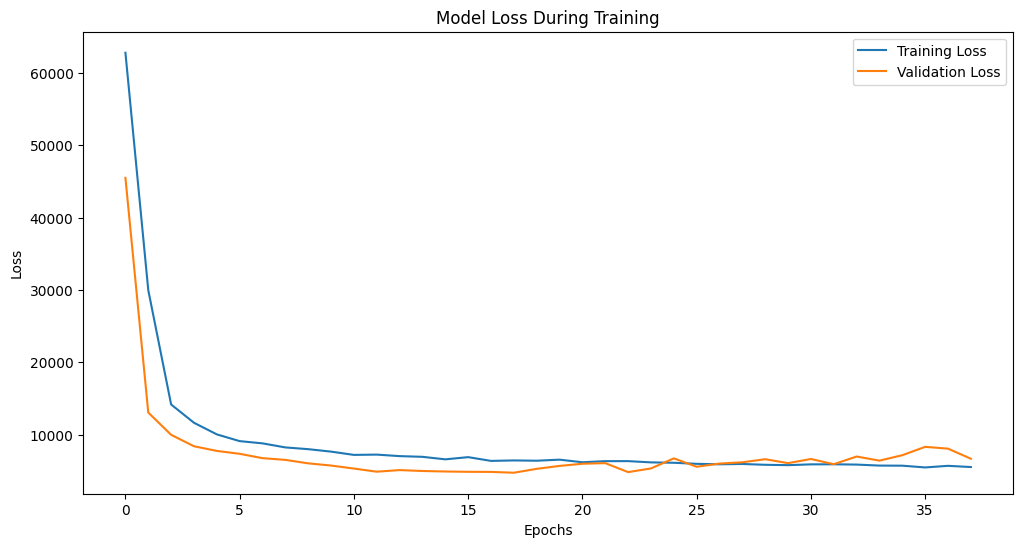

In [83]:
#Plotting training history 

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [84]:
# %% 
print("Hello")

Hello


In [ ]:
#Make predictions and Evaluate the Model

import numpy as np

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

training_predictions = model.predict(training_features)
validation_predictions = model.predict(validation_features)
print(f"MAPE on the Training Data: {mape(training_labels, training_predictions):.2f}%")
print(f"MAPE on the Validation Data: {mape(validation_labels, validation_predictions):.2f}%")

In [ ]:
#Visualizing Predictions vs Actual Values


def plot_predictions(data, title):
    plt.figure(figsize=(12, 6))
    plt.plot(data['actual'], label='Actual Values', color='red')
    plt.plot(data['prediction'], label='Predicted Values', color='blue')
    plt.title(title)
    plt.xlabel('Day')
    plt.ylabel('Umsatz')
    plt.legend()
    plt.show()



# Ensure that training_predictions, validation_predictions, training_labels, and validation_labels are numpy arrays
training_predictions = np.array(training_predictions).flatten()
validation_predictions = np.array(validation_predictions).flatten()
training_labels = np.array(training_labels).flatten()
validation_labels = np.array(validation_labels).flatten()

# print the type of the predictions
print(type(training_predictions))
print(type(validation_predictions))

# Create DataFrames with 1-dimensional arrays
data_train = pd.DataFrame({'prediction': training_predictions, 'actual': training_labels})
data_validation = pd.DataFrame({'prediction': validation_predictions, 'actual': validation_labels})

# Plot predictions
plot_predictions(data_train.head(100), 'Predicted and Actual Values for the Training Data')
plot_predictions(data_validation.head(100), 'Predicted and Actual Values for the Validation Data')